# Step 3 - Stationarity and Structural Break Walkthrough

This notebook is the notebook version of `src/03_stationarity.py`.

**What this notebook explains:**
- why the raw import series is not ready for ARIMA in levels
- why log-differencing is used in the project
- how the 2018 break is statistically justified
- how the diagnostic charts connect to later ARIMA / ARIMAX modeling

## Notebook flow
1. Set up the environment
2. Load the annual import series
3. Build level, log, and differenced versions
4. Run ADF and KPSS tests
5. Run the Chow structural break test
6. Plot the diagnostics
7. Save the text report used by the rest of the project


In [1]:
from pathlib import Path
import os
import sys
filterwarnings = True
if filterwarnings:
    import warnings
    warnings.filterwarnings("ignore")

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(path for path in candidates if (path / "config.py").exists())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats as sp_stats
from scipy.stats import f as f_dist
from config import ANNUAL_FILE, CHART_DIR, REPORT_DIR, BREAK_YEAR

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
})

NAVY = "#0f2744"
BLUE = "#1d4ed8"
RED = "#dc2626"
GRAY = "#64748b"
GREEN = "#16a34a"


## Load the annual series

We only need the annual integrated dataset here. The country breakdown is useful for supplier analysis, but stationarity testing is done on the aggregate real import series.


In [2]:
ann = pd.read_csv(ANNUAL_FILE)
ann["year"] = ann["year"].astype(int)
ann = ann.sort_values("year").reset_index(drop=True)

series_level = ann["real_value_2015usd_billions"].dropna()
series_log = np.log(series_level)
series_diff = series_level.diff().dropna()
series_logdiff = series_log.diff().dropna()

pd.DataFrame(
    {
        "series": ["level", "log", "first difference", "log first difference"],
        "observations": [len(series_level), len(series_log), len(series_diff), len(series_logdiff)],
        "why_it_matters": [
            "Raw modeling target",
            "Stabilizes scale",
            "Measures absolute change",
            "Measures proportional change and is the model-ready series",
        ],
    }
)


,series,observations,why_it_matters
0,level,30,Raw modeling target
1,log,30,Stabilizes scale
2,first difference,29,Measures absolute change
3,log first difference,29,Measures proportional change and is the model-...


## Create reusable test helpers

We use two stationarity tests because they ask opposite questions:
- **ADF**: null hypothesis is non-stationarity
- **KPSS**: null hypothesis is stationarity

When both point in the same direction, the conclusion is much easier to trust.


In [3]:
def run_adf(series, label, maxlag=None):
    lag = maxlag if maxlag is not None else max(1, int(np.sqrt(len(series))))
    lag = min(lag, len(series) // 2 - 1)
    stat, pval, *_ = adfuller(series, maxlag=lag, autolag="AIC")
    return {
        "test": "ADF",
        "series": label,
        "statistic": stat,
        "p_value": pval,
        "stationary": pval < 0.05,
    }


def run_kpss(series, label):
    stat, pval, *_ = kpss(series, regression="c", nlags="auto")
    return {
        "test": "KPSS",
        "series": label,
        "statistic": stat,
        "p_value": pval,
        "stationary": pval > 0.05,
    }


## Run the stationarity tests

The working expectation for this project is:
- level series: **not stationary**
- log-differenced series: **stationary**


In [4]:
results = [
    run_adf(series_level, "Real imports (level)"),
    run_kpss(series_level, "Real imports (level)"),
    run_adf(series_logdiff, "Log-differenced real imports"),
    run_kpss(series_logdiff, "Log-differenced real imports"),
]
results_df = pd.DataFrame(results)
results_df


C:\Users\Pegasus\AppData\Local\Temp\ipykernel_2676\4043747856.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(series, regression="c", nlags="auto")


,test,series,statistic,p_value,stationary
0,ADF,Real imports (level),2.0856,0.9988,False
1,KPSS,Real imports (level),0.6345,0.0195,False
2,ADF,Log-differenced real imports,-5.9923,0.0000,True
3,KPSS,Log-differenced real imports,0.2073,0.1000,True


## Read the test results like a modeler

If the level series fails stationarity and the log-differenced series passes, then the later forecast should be built on the log series with one difference. That is exactly why the project searches `ARIMA(p,1,q)` rather than modeling the raw level directly.


In [5]:
results_df[["series", "test", "p_value", "stationary"]]


,series,test,p_value,stationary
0,Real imports (level),ADF,0.9988,False
1,Real imports (level),KPSS,0.0195,False
2,Log-differenced real imports,ADF,0.0000,True
3,Log-differenced real imports,KPSS,0.1000,True


## Run the Chow test for a 2018 break

This checks whether one straight-line relationship fits the whole period poorly compared with fitting separate lines before and after 2018.


In [6]:
col = "real_value_2015usd_billions"
pre = ann[ann["year"] < BREAK_YEAR].copy()
post = ann[ann["year"] >= BREAK_YEAR].copy()


def sse(frame):
    slope, intercept, *_ = sp_stats.linregress(frame["year"], frame[col])
    residuals = frame[col] - (slope * frame["year"] + intercept)
    return (residuals ** 2).sum()

sse_pre = sse(pre)
sse_post = sse(post)
sse_all = sse(ann)
k = 2
n1, n2 = len(pre), len(post)
F_stat = ((sse_all - sse_pre - sse_post) / k) / ((sse_pre + sse_post) / (n1 + n2 - 2 * k))
p_chow = 1 - f_dist.cdf(F_stat, k, n1 + n2 - 2 * k)

pd.DataFrame(
    {
        "break_year": [BREAK_YEAR],
        "F_statistic": [F_stat],
        "p_value": [p_chow],
        "confirmed": [p_chow < 0.05],
    }
)


,break_year,F_statistic,p_value,confirmed
0,2018,242.6915,0.0000,True


## Plot 1 - level, log, and differenced views

This figure lets you see the stationarity problem visually instead of only statistically.


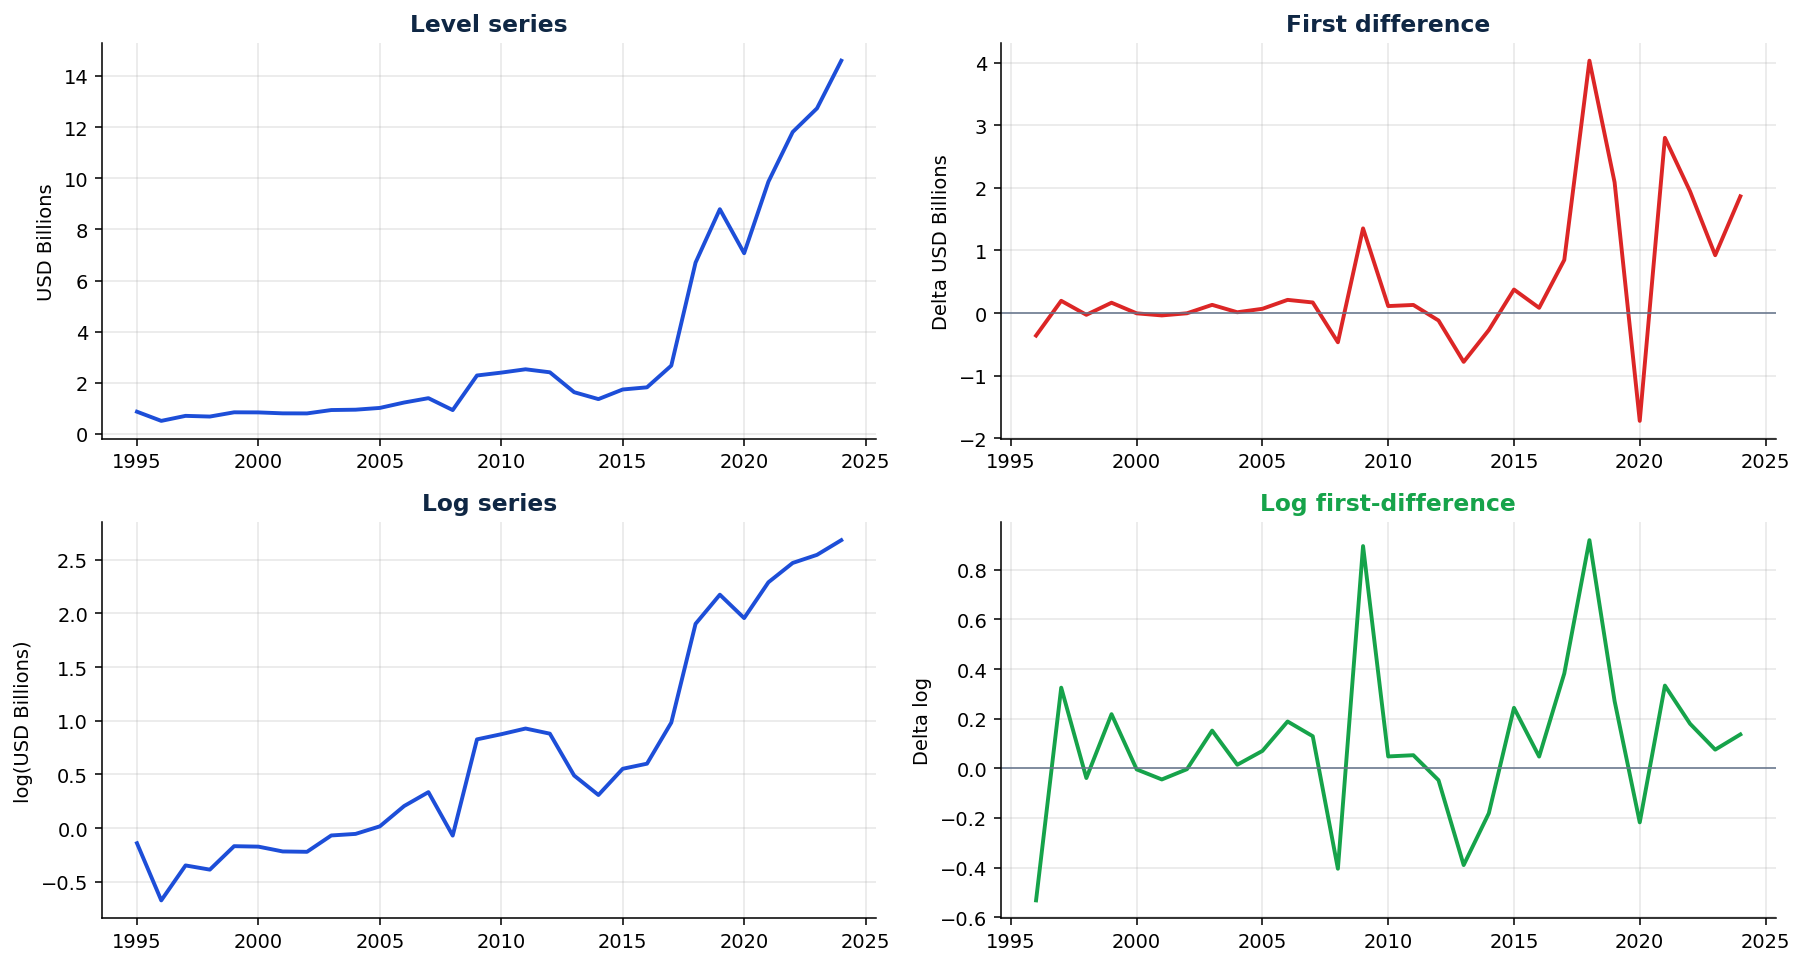

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].plot(ann["year"], series_level, color=BLUE, lw=2)
axes[0, 0].set_title("Level series", fontweight="bold", color=NAVY)
axes[0, 0].set_ylabel("USD Billions")

axes[0, 1].plot(ann["year"][1:], series_diff, color=RED, lw=2)
axes[0, 1].axhline(0, color=GRAY, lw=0.8)
axes[0, 1].set_title("First difference", fontweight="bold", color=NAVY)
axes[0, 1].set_ylabel("Delta USD Billions")

axes[1, 0].plot(ann["year"], series_log, color=BLUE, lw=2)
axes[1, 0].set_title("Log series", fontweight="bold", color=NAVY)
axes[1, 0].set_ylabel("log(USD Billions)")

axes[1, 1].plot(ann["year"][1:], series_logdiff, color=GREEN, lw=2)
axes[1, 1].axhline(0, color=GRAY, lw=0.8)
axes[1, 1].set_title("Log first-difference", fontweight="bold", color=GREEN)
axes[1, 1].set_ylabel("Delta log")

for axis in axes.flat:
    axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CHART_DIR) / "stat_01_level_vs_diff.png")
plt.show()


## Plot 2 - structural break around 2018

This chart shows how much steeper the post-2018 trend is than the earlier regime.


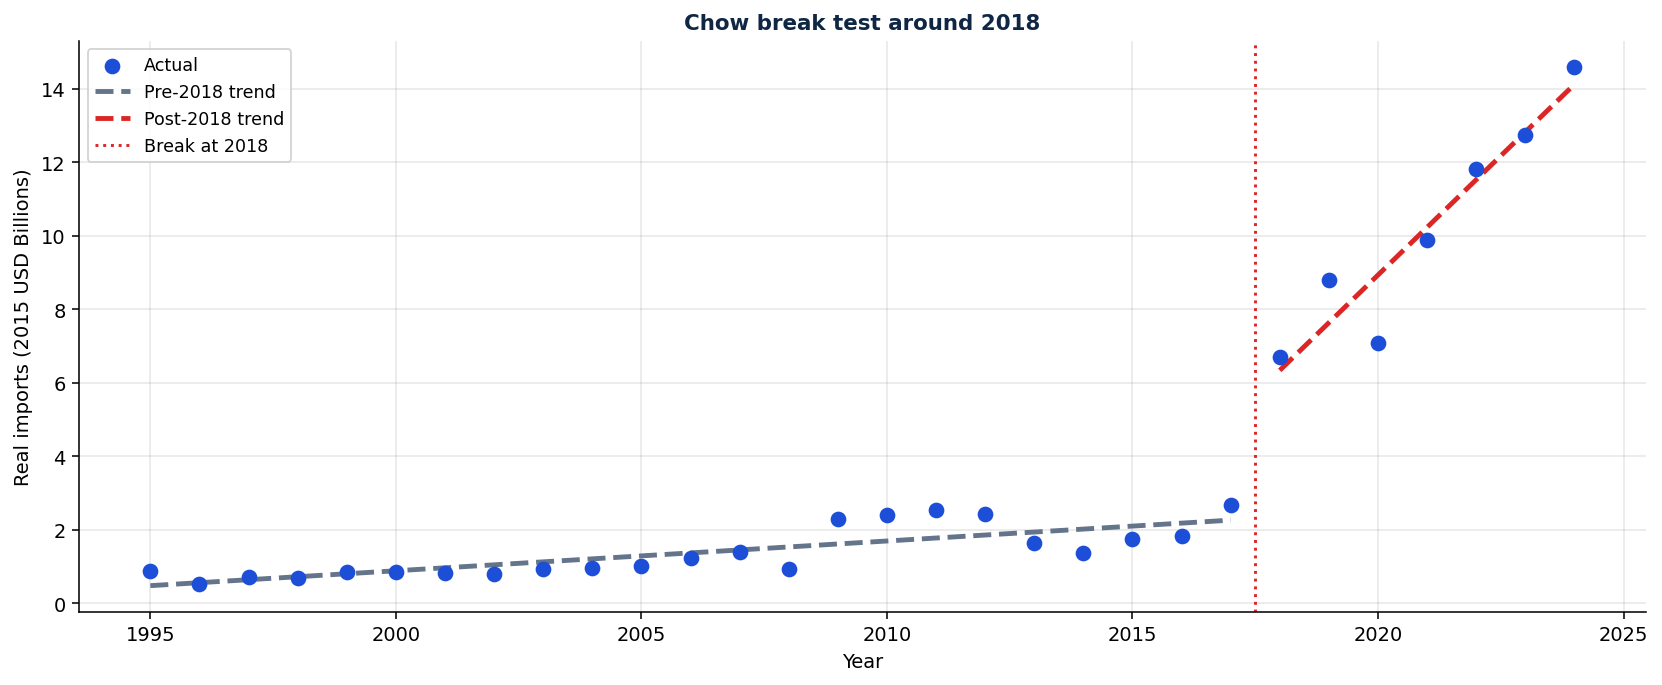

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(ann["year"], ann[col], color=BLUE, s=50, zorder=3, label="Actual")
pre_slope, pre_intercept, *_ = sp_stats.linregress(pre["year"], pre[col])
post_slope, post_intercept, *_ = sp_stats.linregress(post["year"], post[col])
yrs_pre = np.array(pre["year"])
yrs_post = np.array(post["year"])
ax.plot(yrs_pre, pre_slope * yrs_pre + pre_intercept, color=GRAY, lw=2.5, linestyle="--", label=f"Pre-{BREAK_YEAR} trend")
ax.plot(yrs_post, post_slope * yrs_post + post_intercept, color=RED, lw=2.5, linestyle="--", label=f"Post-{BREAK_YEAR} trend")
ax.axvline(BREAK_YEAR - 0.5, color=RED, lw=1.5, linestyle=":", label=f"Break at {BREAK_YEAR}")
ax.set_xlabel("Year")
ax.set_ylabel("Real imports (2015 USD Billions)")
ax.set_title(f"Chow break test around {BREAK_YEAR}", fontsize=11, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(Path(CHART_DIR) / "stat_02_structural_break.png")
plt.show()


## Plot 3 - ACF and PACF of the model-ready series

These are the lag diagnostics that inform the ARIMA order search in the next step.


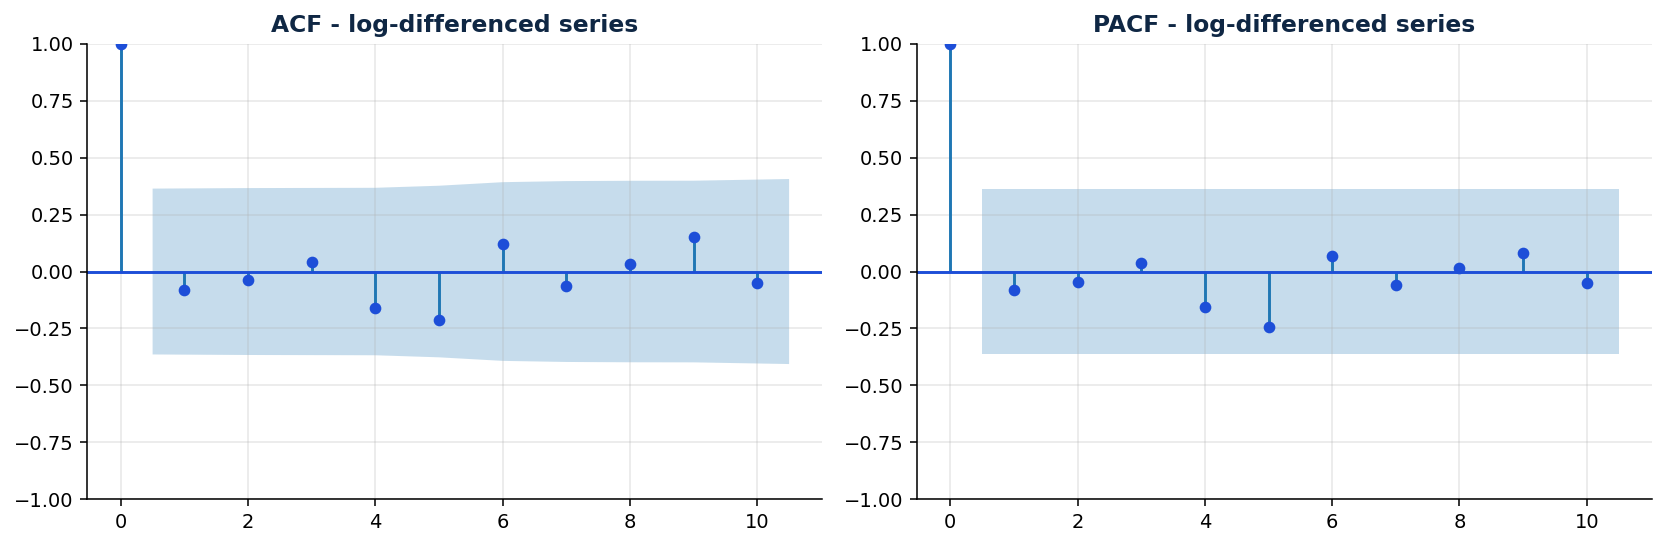

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
max_lags = min(10, len(series_logdiff) // 2 - 1)
plot_acf(series_logdiff, lags=max_lags, ax=ax1, color=BLUE, title="")
plot_pacf(series_logdiff, lags=max_lags, ax=ax2, color=BLUE, title="")
ax1.set_title("ACF - log-differenced series", fontweight="bold", color=NAVY)
ax2.set_title("PACF - log-differenced series", fontweight="bold", color=NAVY)
plt.tight_layout()
plt.savefig(Path(CHART_DIR) / "stat_03_acf_pacf.png")
plt.show()


## Save the report used by the pipeline

The rest of the project still expects a text file in `outputs/reports`, so the notebook keeps that side effect.


In [10]:
report_path = Path(REPORT_DIR) / "stationarity_report.txt"

report_lines = [
    "SEMITRACK INDIA - Stationarity Report",
    "=" * 65,
    ""
]

for row in results:
    report_lines.append(str(row))

report_lines.extend([
    "",
    f"Chow test: F={F_stat:.3f}, p={p_chow:.4f}, confirmed={p_chow < 0.05}",
    f"Conclusion: use the log series with one difference and include the {BREAK_YEAR} break in ARIMAX."
])

report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8"
)

898